# EDA?
- Exploratory Data Analysis (탐색적 데이터 분석)은 본격적인 머신러닝 모델을 만들기 전에 데이터를 이해하는 과정
- e.g., 요리 시작 전 냉장고를 열어서 재료가 뭐가 있는지, 상한건 없는지, 양은 충분한지 확인하는 것
-----------------------------------------------------------
# Step2. EDA
1. 데이터 불러오기 & 기본 구조 파악
- CSV 파일을 Pandas로 읽기
- 행/열 수, 변수명, 데이터 타입 확인
- 결측치 현황 파악
- 기술통계 요약 (describe)

2. 분포 시각화
- 타겟 변수 (click): 클릭 65% / 미클릭 35% 비율 확인
- 수치형 변수 (age): 전체 분포 및 클릭 여부별 분포 비교
- 범주형 변수 (gender, device_type 등): 카테고리별 빈도 및 클릭률 비교

3. 데이터 전처리 & 분할
- 불필요한 열 제거 (id, full_name)
- 결측치 처리: 수치형(age) → 중앙값, 범주형 → 최빈값
- One-hot Encoding: 범주형 변수 숫자로 변환 (7열 → 19열)
- X (입력변수) / y (타겟: click) 분리
- Train / Validation / Test 셋 분할 (80 / 10 / 10), stratify로 클릭 비율 유지

4. 상관관계 분석
- 전체 변수 간 상관관계 히트맵
- click과 각 변수의 상관계수 순위 도출
- 단일 변수로는 클릭 예측이 어려움 확인 → feature interaction 고려 필요
-----------------------------------------------------------
# 사용할 라이브러리
- pandas: 데이터 불러오고 표처럼 다루기 like Excel
- matplotlib / seaborn: 그래프 그리기 like 차트 도구
- sklearn: 데이터 분할, 인코딩 등 ML 도구 like 분석 도구함

# EDA 전체 결과 요약
## 1. 데이터 불러오기 & 기본 구조 파악
- 10,000행 × 9열, 분석 변수 7개 (id, full_name 제외)
- 타겟 변수 click: 클릭 65% / 미클릭 35% > 클래스 불균형 존재
- 결측치 최대 48% > 전처리가 분석 품질을 좌우하는 핵심 변수

## 2. 기술통계 & 분포 시각화
- age는 18~64세 전 구간에 고르게 분포, 50대에서만 미클릭이 살짝 우세
- 모든 범주형 변수에서 카테고리별 클릭률이 전체 평균(65%)과 거의 동일
- 어떤 단일 변수도 클릭률에 뚜렷한 차이를 만들지 못함

## 3. 데이터 전처리
- 결측치 처리: 수치형(age) > 중앙값, 범주형 > 최빈값
- One-hot Encoding으로 범주형 변수 숫자 변환 (7열 > 19열)
- Train 8,000 / Validation 1,000 / Test 1,000으로 분할
- 3 세트 모두 클릭 비율 0.65로 동일하게 유지 (stratify 성공)

## 4. 상관관계 분석
- click과 모든 변수의 상관계수가 0.06 이하 > 통계적으로 유의미한 상관관계 없음
- 그나마 상위권은 age, browsing_history_Entertainment, browsing_history_News
- gender, device_type_Tablet은 최하위 > 모델에서 중요도 낮을 가능성 높음

## EDA 핵심 인사이트
1. 이 데이터셋은 변수 수가 제한적이고 단순 상관관계가 매우 낮아, 단독 변수로는 클릭 예측이 어려움 → Proposal에서 예상했던 한계가 EDA에서 실제로 확인됨
2. 변수 간 조합(feature interaction)을 고려하는 모델이 필요 → 다음 단계(Step 3 Progress Update)에서 Logistic Regression / Decision Tree / Random Forest 3가지 모델을 비교하여 최적 모델 선정 예정

# Step1. 데이터 불러오기 & 기본 구조 파악
1. 라이브러리 불러오기
2. 데이터 불러오기
3. 데이터 크기와 구조 확인
4. 결측치 현황 파악
5. 기본 통계 요약

In [72]:
# 1-1. 라이브러리 불러오기
# ----------------------------
# 현재 노트북이 사용하는 파이썬에 라이브러리 설치
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

# pandas: 데이터를 표 (DataFrame) 형태로 다루는 도구 (like Excel)
# numpy: 숫자 계산을 빠르게 해주는 도구
# matplotlib, seaborn: 그래프를 그리는 도구
# %matplotlib inline: 그래프를 노트북 안에 바로 표시되게 하는 설정

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\minru\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [73]:
# 한글 폰트 설정 (윈도우)
# matplotlib은 기본적으로 한글 폰트가 없어서 따로 설정해줘야 함
# 'Malgun Gothic' = 윈도우 기본 한글 폰트 '맑은 고딕'
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False  
# 음수 기호(-)가 깨지는 것도 함께 방지

# 설정 확인
print("폰트 설정 완료!")

폰트 설정 완료!


In [74]:
# 1-2. 데이터 불러오기
# ----------------------------
# pd.read_csv(): CSV 파일을 읽어서 DataFrame으로 저장
# DataFrame = 행(row)과 열(column)로 이루어진 표
# df는 'dataframe'의 약어로 관례적으로 많이 사용

# r'경로' 형태로 쓰면 윈도우에서 백슬래시(\) 문제 해결됨
df = pd.read_csv(r'C:\Users\minru\Desktop\KU MSBA\Module 1\4) BA Programming\Team PJT\step2_EDA\ad_click_dataset.csv')

# 데이터가 잘 불러와졌는지 앞에서 5개 행만 미리보기
df.head()

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


In [75]:
# 1-3. 데이터 크기와 구조 확인
# ----------------------------
# .shape: (행 수, 열 수)
# 10,000행, 9개 열이어야 정상
print("데이터 크기", df.shape)

# .dtypes: 각 열의 데이터 타입 확인
# int64/float64 = 숫자, object = 문자 (범주형)
print("\n각 열의 데이터 타입:")
print(df.dtypes)

데이터 크기 (10000, 9)

각 열의 데이터 타입:
id                    int64
full_name               str
age                 float64
gender                  str
device_type             str
ad_position             str
browsing_history        str
time_of_day             str
click                 int64
dtype: object


In [76]:
# 1-4. 결측치 현황 파악
# ----------------------------
# isnull(): 결측치면 True, 아니면 False를 반환
# .sum(): True의 개수 (=결측치 개수)를 합산
# 결측치 개수와 비율을 한눈에 보기 좋게 DataFrame으로 정리

missing_count = df.isnull().sum()                       # 결측치 개수
missing_ratio = (df.isnull().sum() / len(df)) * 100     # 결측치 비율(%)

missing_df = pd.DataFrame({
    '결측치 개수': missing_count,
    '결측치 비율(%)': missing_ratio.round(1)             # 소수점 1자리로 반올림
})

print(missing_df)


                  결측치 개수  결측치 비율(%)
id                     0        0.0
full_name              0        0.0
age                 4766       47.7
gender              4693       46.9
device_type         2000       20.0
ad_position         2000       20.0
browsing_history    4782       47.8
time_of_day         2000       20.0
click                  0        0.0


In [77]:
# 1-5. 기본 통계 요약
# ----------------------------
# .describe(): 수치형  변수의 기술통계량을 자동으로 계산해줌
# count(개수), mean(평균), std(표준편차), min(최솟값), max(최댓값), unique(고유값 수), top(가장 많은 값), freq(top의 빈도) 등 포함
# include = 'all'을 추가하면 범주형 변수도 같이 보여줌

df.describe(include = 'all')

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
count,10000.000000,10000,5234.000000,5307,8000,8000,5218,8000,10000.000000
unique,NaN,4000,NaN,3,3,3,5,4,NaN
top,NaN,User1171,NaN,Female,Desktop,Bottom,Entertainment,Morning,NaN
freq,NaN,25,NaN,1834,2754,2817,1175,2126,NaN
mean,5060.211400,NaN,40.197363,NaN,NaN,NaN,NaN,NaN,0.650000
std,2861.758265,NaN,13.126420,NaN,NaN,NaN,NaN,NaN,0.476993
min,5.000000,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,2529.000000,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,5218.000000,NaN,39.500000,NaN,NaN,NaN,NaN,NaN,1.000000
75%,7466.000000,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,1.000000


# Step2. 기술 통계 & 분포 시각화
1. 타겟 변수 분포: click 클릭 / 미클릭 확인
2. 수치형 분포 확인: age 분포 확인
3. 범주형 변수 분포: gender, device_type 등 각 카테고리별 비율 확인
4. 변수와 click의 관계: 각 변수와 클릭 간 관계 확인

click 분포:
click
1    6500
0    3500
Name: count, dtype: int64

click 비율(%):
click
1    65.0
0    35.0
Name: count, dtype: float64


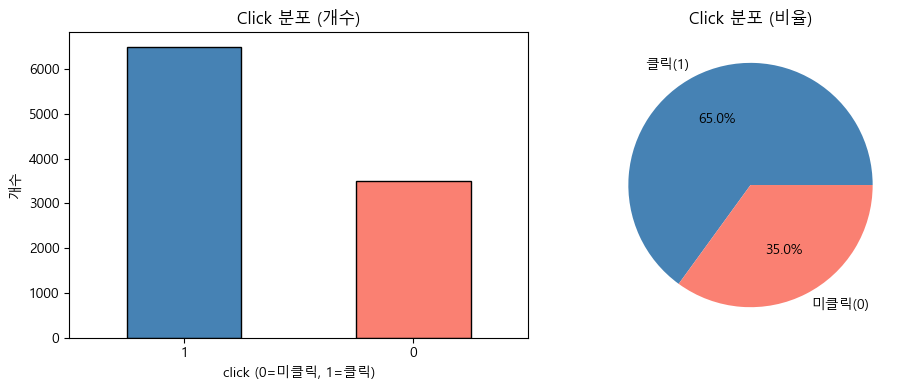

In [39]:
# 2-1. 타겟 변수 (click) 분포 확인
# ----------------------------
# 타겟 변수 click의 분포 확인
# click: 1 = 클릭, 0 = 미클릭

# value_counts(): 각 값이 몇 번 등장하는지 카운트
print("click 분포:")
print(df['click'].value_counts())
print("\nclick 비율(%):")
print((df['click'].value_counts() / len(df) * 100).round(1))

# 막대 그래프로 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# fig: 전체 그림 틀, axes: 그래프 2개를 나란히 배치 (1행 2열)

# 왼쪽: 개수 막대그래프
df['click'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Click 분포 (개수)')   # 그래프 제목
axes[0].set_xlabel('click (0=미클릭, 1=클릭)')  # x축 이름
axes[0].set_ylabel('개수')               # y축 이름
axes[0].tick_params(axis='x', rotation=0)  # x축 글자 회전 없이
 
# 오른쪽: 비율 파이차트
df['click'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', labels=['클릭(1)', '미클릭(0)'], colors=['steelblue', 'salmon'])
axes[1].set_title('Click 분포 (비율)')
axes[1].set_ylabel('')  # 파이차트 기본 y축 라벨 제거

plt.tight_layout()  # 그래프 간격 자동 조정
plt.show()

# 결과 해석: 클릭 65% vs. 미클릭 35% -> 두 클래스 비율이 다른 클래스 불균형 (imbalance)이 존재. 나중에 ML 모델 만들 때 고려해야 함 

<function matplotlib.pyplot.show(close=None, block=None)>

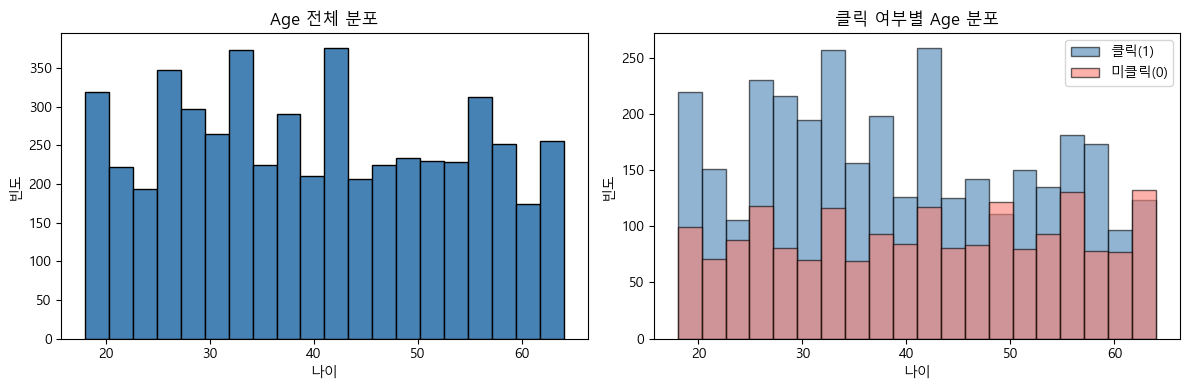

In [51]:
# 2-2. 수치형 변수 (age) 분포 확인
# ----------------------------
# age는 숫자형 변수 -> 히스토그램으로 분포 확인
# 히스토그램 값의 범위를 구간으로 나눠서 각 구간에 몇 개 있는지 막대로 표시

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 전체 age 분포
axes[0].hist(df['age'].dropna(), bins=20, color='steelblue', edgecolor='black')
# .dropna(): 결측치 제외하고 그리기 (결측치 포함하면 오류남)
# bins=20: 막대를 20개 구간으로 나눔
axes[0].set_title('Age 전체 분포')
axes[0].set_xlabel('나이')
axes[0].set_ylabel('빈도')

# 오른쪽: 클릭 여부에 따른 age 분포 비교
# click=1 (클릭한 사람)과 click=0 (안 한 사람)의 나이 분포를 겹쳐서 비교
axes[1].hist(df[df['click']==1]['age'].dropna(), bins=20, alpha=0.6, color='steelblue', edgecolor='black', label='클릭(1)')
axes[1].hist(df[df['click']==0]['age'].dropna(), bins=20, alpha=0.6, color='salmon', edgecolor='black', label='미클릭(0)')
# alpha=0.6: 투명도 설정 (겹치는 부분 보이도록)
axes[1].set_title('클릭 여부별 Age 분포')
axes[1].set_xlabel('나이')
axes[1].set_ylabel('빈도')
axes[1].legend() # 범례 표시

plt.tight_layout()
plt.show


# 결과 해석
- Age 전체 분포: 18~64세 전 구간에 걸쳐 고르게 분포되어 있음. 특정 나이대에 몰려있지 않음 (나이 편향 x)
- 클릭 여부별 Age 분포: 전반적으로 클릭이 미클릭보다 많지만, 50대, 60대 구간에서는 미클릭이 더 많은 구간 존재
- 50~60대는 광고 클릭률이 상대적으로 낮은 연령대일 수 있으나 나이대별 차이가 극적이진 않음. Age 단독으로는 클릭 예측력이 크지 않을 수 있음

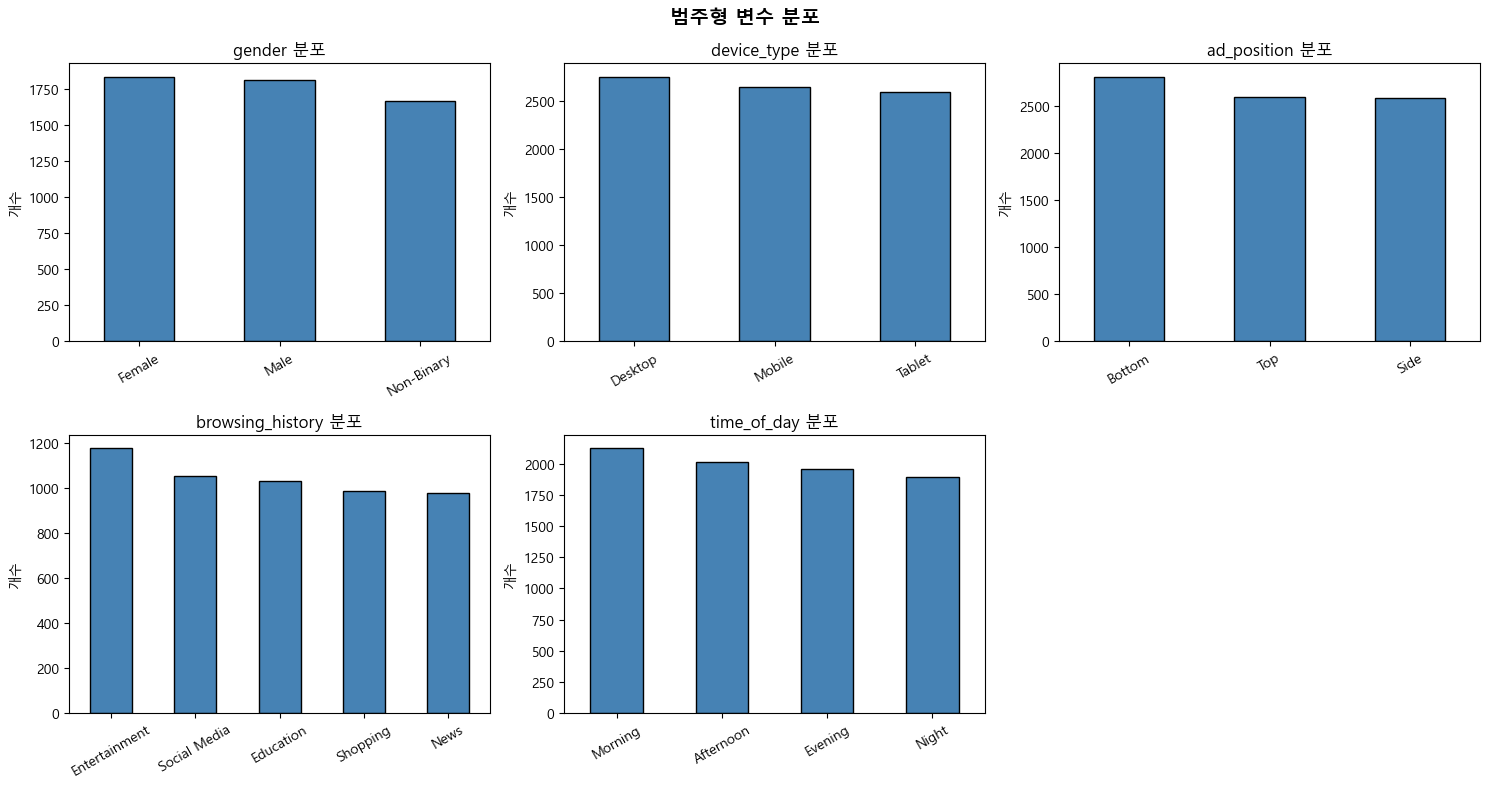

In [56]:
# 2-3. 범주형 변수 분포 확인
# ----------------------------
# 범주형 변수 4개를 한 번에 시각화
# gender, device_type, ad_position, browsing_history, time_of_day

cat_cols = ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']
# 분석할 범주형 변수 목록을 리스트로 저장

fig, axes = plt.subplots(2, 3, figsize=(15, 8)) # 2행 3열로 그래프 배치
axes = axes.flatten()
# 2차원 배열([[ax1,ax2,ax3],[ax4,ax5,ax6]])을 1차원([ax1,ax2,...,ax6])으로 펴줌
# → for문에서 axes[0], axes[1]... 처럼 순서대로 쓰기 위해

for i, col in enumerate(cat_cols):
    # enumerate: 리스트를 순서(i)와 값(col)을 동시에 꺼내줌
    # i=0이면 col='gender', i=1이면 col='device_type' ...

    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col} 분포')    # f'': 변수를 문자열 안에 넣는 방법
    axes[i].set_xlabel('')
    axes[i].set_ylabel('개수')
    axes[i].tick_params(axis='x', rotation=30)  # x축 글자 30도 기울임

axes[5].set_visible(False)  # 마지막 빈 칸 숨기기 (5개 변수, 6칸이라 1칸 남음)

plt.suptitle('범주형 변수 분포', fontsize=14, fontweight='bold')
# suptitle: 전체 그림의 큰 제목
plt.tight_layout()
plt.show()

# 결과 해석
- 각 카테고리별 고르게 분포

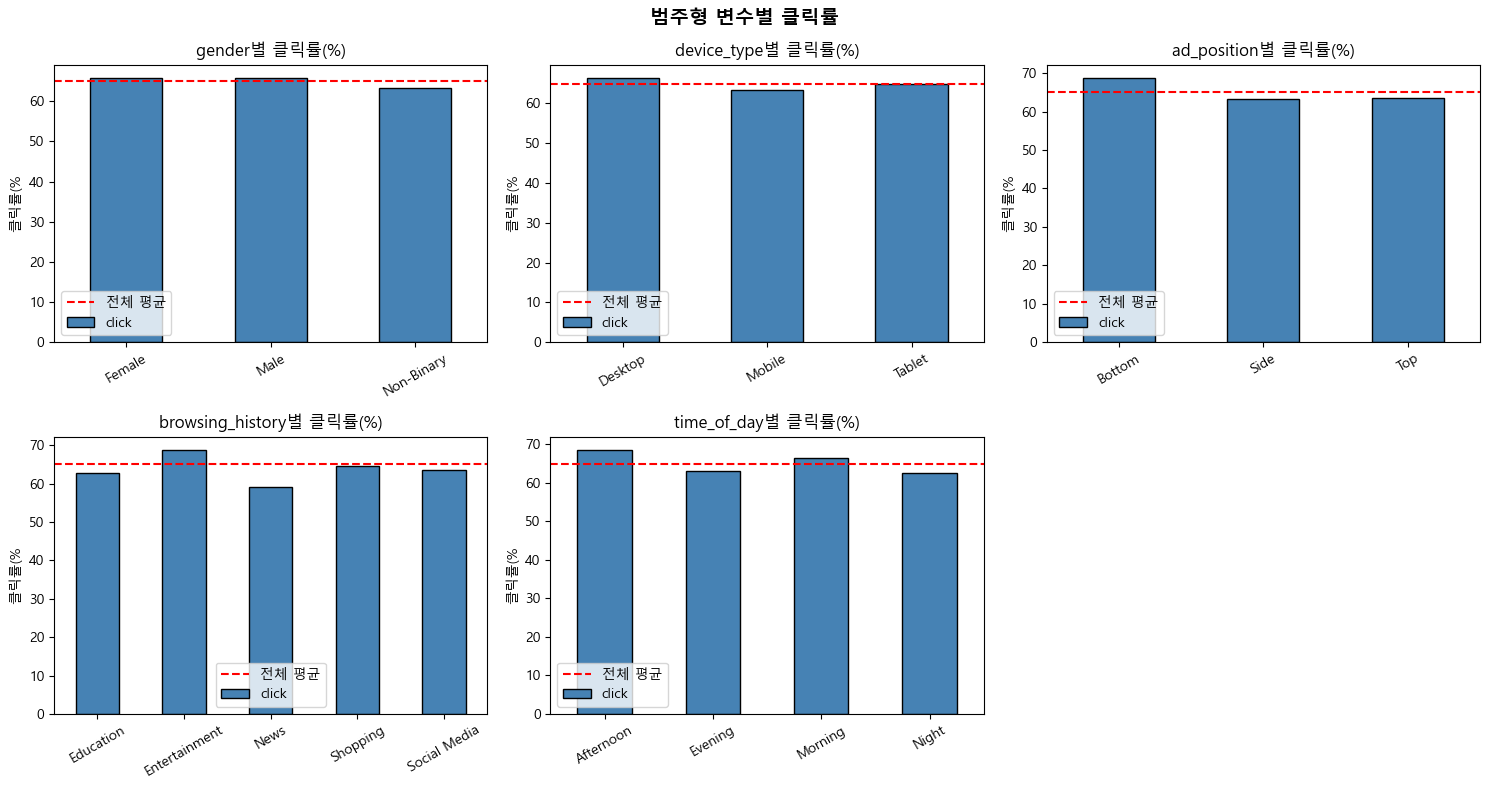

In [57]:
# 2-4. 범주형 변수와 click의 관계
# ----------------------------
# 각 범주형 변수별로 클릭률이 어떻게 다른지 확인
# groupby: 특정 변수 기준으로 데이터를 그룹으로 묶어줌

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # 각 카테고리별 클릭률(평균) 계산
    click_rate = df.groupby(col)['click'].mean() * 100
    # groupby(col): col 기준으로 그룹 묶기
    # ['click'].mean(): 각 그룹에서 click의 평균 = 클릭률
    # *100: 비율을 %로 변환

    click_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col}별 클릭률(%)')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('클릭률(%')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=df['click'].mean()*100, color='red', linestyle='--', linewidth=1.5, label='전체 평균')
    # axhline: 수평선 그리기 -> 전체 평균 클릭률 기준선으로 표시
    axes[i].legend()

axes[5].set_visible(False)

plt.suptitle('범주형 변수별 클릭률', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 결과 해석
- 모든 변수에서 막대 높이가 전체 평균 (빨간 점선)과 거의 비슷함 -> 어떤 변수도 클릭률에 큰 차이를 만들지 않음
- 모든 막대가 평균 근처에 몰려있음 -> 이 데이터셋의 변수들이 클릭 여부를 잘 설명하지 못할 수 있음
- Proposal의 변수 수 제한적 + 출처 불명확하여 모델 예측력 낮을 수 있음이 확임 > 한계점*

# Step3. 데이터 전처리
## EDA 중 가장 핵심 단계. 결측치가 최대 48%로 결측치 처리 방법에 따라 분석 결과가 크게 바뀜
1. 분석에 불필요한 열 제거 > id, full_name
2. 결측치 처리 > 빠진 값을 어떻게 채울지
3. 범주형 변수 숫자로 변환 > ML 모델은 문자를 못 읽음
4. X/y 분리 > 입력변수/타겟변수 나누기
5. Train / Validation / Test 분할 > 80 / 10 /10

## 전처리 전체 흐름
원본 데이터 (10,000행 × 9열)
       ↓
불필요한 열 제거 (id, full_name)
       ↓
결측치 처리 (수치형 > 중앙값, 범주형 >최빈값)
       ↓
One-hot Encoding (범주형 > 숫자)
       ↓
X / y 분리
       ↓
Train(8,000) / Validation(1,000) / Test(1,000)

In [ ]:
# 3-1. 불필요한 열 제거
# ----------------------------
# id, full_name은 단순 식별자라 클릭 예측에 아무 의미 없음 > 제거
# drop(): 지정한 열 (Column) 또는 행을 제거
# axis=1: 열 방향으로 제거 (axis=0 이면 행 방향)
# inplace=True: 원본 df를 직접 수정 (False면 새 변수에 저장해야 함)

df = df.drop(columns=['id', 'full_name'])

print("제거 후 열 목록:", df.columns.tolist())
print("데이터 크기: ", df.shape)    # 9개 > 7개

제거 후 열 목록: ['age', 'gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day', 'click']
데이터 크기:  (10000, 7)


In [63]:
# 3-2. 결측치 처리
# ----------------------------
# 결측치 처리 전략
# - 수치형(age): 중앙값(median)으로 채우기
#   → 평균(mean)은 극단값에 민감해서 중앙값이 더 안정적
# - 범주형(gender 등): 최빈값(mode)으로 채우기
#   → 가장 많이 등장하는 값으로 채우는 것이 가장 자연스러움

# 수치형: age > 중앙값으로 채우기
df['age'] = df['age'].fillna(df['age'].median())

# 범주형: 나머지 변수 > 최빈값으로 채우기
cat_cols = ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day', 'click']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    # mode()[0]: 최빈값이 여러 개일 수 있어서 [0]으로 첫 번째 값만 가져옴

# 처리 후 결측치 확인
print("결측치 처리 후:")
print(df.isnull().sum())


결측치 처리 후:
age                 0
gender              0
device_type         0
ad_position         0
browsing_history    0
time_of_day         0
click               0
dtype: int64


In [64]:
# 3-3. 범주형 변수 숫자로 변환 (One-hot Encoding)
# ----------------------------
# ML 모델은 문자 (Male, Female 등)를 바로 처리 못함 > 숫자로 변환 필요
# One-hot Encoding: 카테고리를 0과 1로 이루어진 새 열로 변환
# 예) gender > gender_Male, gender_Female, gender_Non-Binary (각각 0 또는 1)

# click은 이미 0/1 숫자라서 변환 대상에서 제외
encode_cols = ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']

df_encoded = pd.get_dummies(df, columns=encode_cols)
# pd.get_dummies(): 지정한 범주형 열을 자동으로 One-hot Encoding
# 원본 df는 그대로 두고 df_encoded라는 새 변수에 저장

# click 열의 타입을 정수(int)로 변환
df_encoded['click'] = df_encoded['click'].astype(int)

print("인코딩 후 열 목록:")
print(df_encoded.columns.tolist())
print("\n데이터 크기:", df_encoded.shape)

인코딩 후 열 목록:
['age', 'click', 'gender_Female', 'gender_Male', 'gender_Non-Binary', 'device_type_Desktop', 'device_type_Mobile', 'device_type_Tablet', 'ad_position_Bottom', 'ad_position_Side', 'ad_position_Top', 'browsing_history_Education', 'browsing_history_Entertainment', 'browsing_history_News', 'browsing_history_Shopping', 'browsing_history_Social Media', 'time_of_day_Afternoon', 'time_of_day_Evening', 'time_of_day_Morning', 'time_of_day_Night']

데이터 크기: (10000, 20)


# 결과 해석
- 기존 7개 열이 범주형 변수들이 펼쳐지면서 열이 많아짐. e.g., gender 1개 > gender_Male, gender_Female, gender_Non-Binary 3개로 늘어남

In [66]:
# 3-4. X / y 분리
# ----------------------------
# X: 모델에 입력할 변수들 (click 제외한 모든 열)
# y: 예측할 타겟 변수 (click)
# 관례적으로 X는 대문자, y는 소문자로 씀

X = df_encoded.drop(columns=['click'])  # click 열 제외한 나머지
y = df_encoded['click'] # click 열만

print("X 크기:", X.shape)   # (10000, 열 수)
print("y 크기:", y.shape)    # (10000,)
print("\ny 값 분포:")
print(y.value_counts())

X 크기: (10000, 19)
y 크기: (10000,)

y 값 분포:
click
1    6500
0    3500
Name: count, dtype: int64


In [71]:
# 3-5. Train / Validation / Test 분할 (80 / 10 / 10)
# ----------------------------
# 데이터를 나누는 이유
# ----------------------------
# ML 모델은 데이터로 "공부(학습)"하고 "시험(평가)"을 봄
# 공부한 문제로 시험보면 당연히 잘 나옴
# 그래서 데이터를 미리 3덩어리로 나눠서 역할을 구분

# Train (훈련용, 80%):      모델이 공부하는 데이터
# Validation (검증용, 10%): 공부하면서 중간중간 실력 확인하는 데이터
# Test (테스트용, 10%):     최종 시험 데이터 > 절대 미리 보면 안 됨
# ----------------------------

from sklearn.model_selection import train_test_split

# 1단계: 전체(100%) > Train(80%) + temp(20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    # test_size=0.2: 전체의 20%를 temp(임시)로 떼어냄
    # 나머지 80%는 자동으로 Train이 됨
    # temp는 아직 Validation/Test로 나누기 전 임시 보관 바구니 같은 개념
    # 최종적으로 temp를 반반 쪼개서 Validation 10%, Test 10% 만듬

    random_state=42,
    # random_state: 데이터를 무작위로 섞어서 나눔
    # 이 "무작위의 기준값(씨앗)"을 고정하는 것
    # 42로 설정하면 > 내가 실행하든, 팀원이 실행하든 항상 똑같이 나뉨
    # 숫자 자체는 의미 없고, 관례적으로 42를 많이 씀 (어떤 숫자든 상관없음)

     stratify=y
    # stratify: 분할 후에도 클릭/미클릭 비율을 원본과 동일하게 유지
    # 원본 데이터: 클릭 65%, 미클릭 35%
    # stratify 없으면 > Train에 클릭 70%, Test에 클릭 55% 이런 식으로 쏠릴 수 있음
    # stratify=y 쓰면 > Train/Val/Test 모두 클릭 65%, 미클릭 35% 유지됨
    # 데이터에 클래스 불균형이 있을 때 특히 중요
)

# 2단계: temp(20%) > Validation(10%) + Test(10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    # X_temp, y_temp: 1단계에서 떼어둔 20% 임시 데이터
    # 이걸 반반으로 나누면 각각 전체의 10%씩이 됨

    test_size=0.5,
    # temp(20%)의 50% = 전체의 10% > Test
    # 나머지 50% = 전체의 10% > Validation

    random_state=42,
    # 위와 동일, 재현 가능하도록 고정

    stratify=y_temp
    # temp 안에서도 클릭/미클릭 비율 유지
)

# 결과 확인
print("Train 크기:", X_train.shape)       # 약 8,000개
print("Validation 크기:", X_val.shape)    # 약 1,000개
print("Test 크기:", X_test.shape)         # 약 1,000개

# 각 세트의 클릭 비율 확인
# stratify가 잘 됐다면 세 값이 모두 약 0.65로 비슷하게 나와야 함
print("\nTrain 클릭 비율:", y_train.mean().round(3))
print("Validation 클릭 비율:", y_val.mean().round(3))
print("Test 클릭 비율:", y_test.mean().round(3))

Train 크기: (8000, 19)
Validation 크기: (1000, 19)
Test 크기: (1000, 19)

Train 클릭 비율: 0.65
Validation 클릭 비율: 0.65
Test 클릭 비율: 0.65


# 결과 해석
## 데이터 크기
- Train 8,000개 / Validation 1,000개 / Test 1,000개 > 80/10/10 비율 정확히 맞음
- 열이 19개 > One-hot Encoding으로 범주형 변수들이 펼쳐진 결과 (원래 7개에서 증가)
## 클릭 비율
- Train / Validation / Test 모두 정확히 0.65로 동일 > stratify가 완벽하게 작동
- 세 세트 모두 클릭 65%, 미클릭 35% 비율 유지 > 모델이 편향 없이 학습하고 평가받을 수 있는 환경 완성

# Step4. 상관관계 분석
## 변수들끼리 얼마나 관련이 있는지 숫자와 그래프로 확인
1. 상관관계 히트맵
2. click과 각 변수의 상관계수 순위
3. click과 상관관계 막대그래프

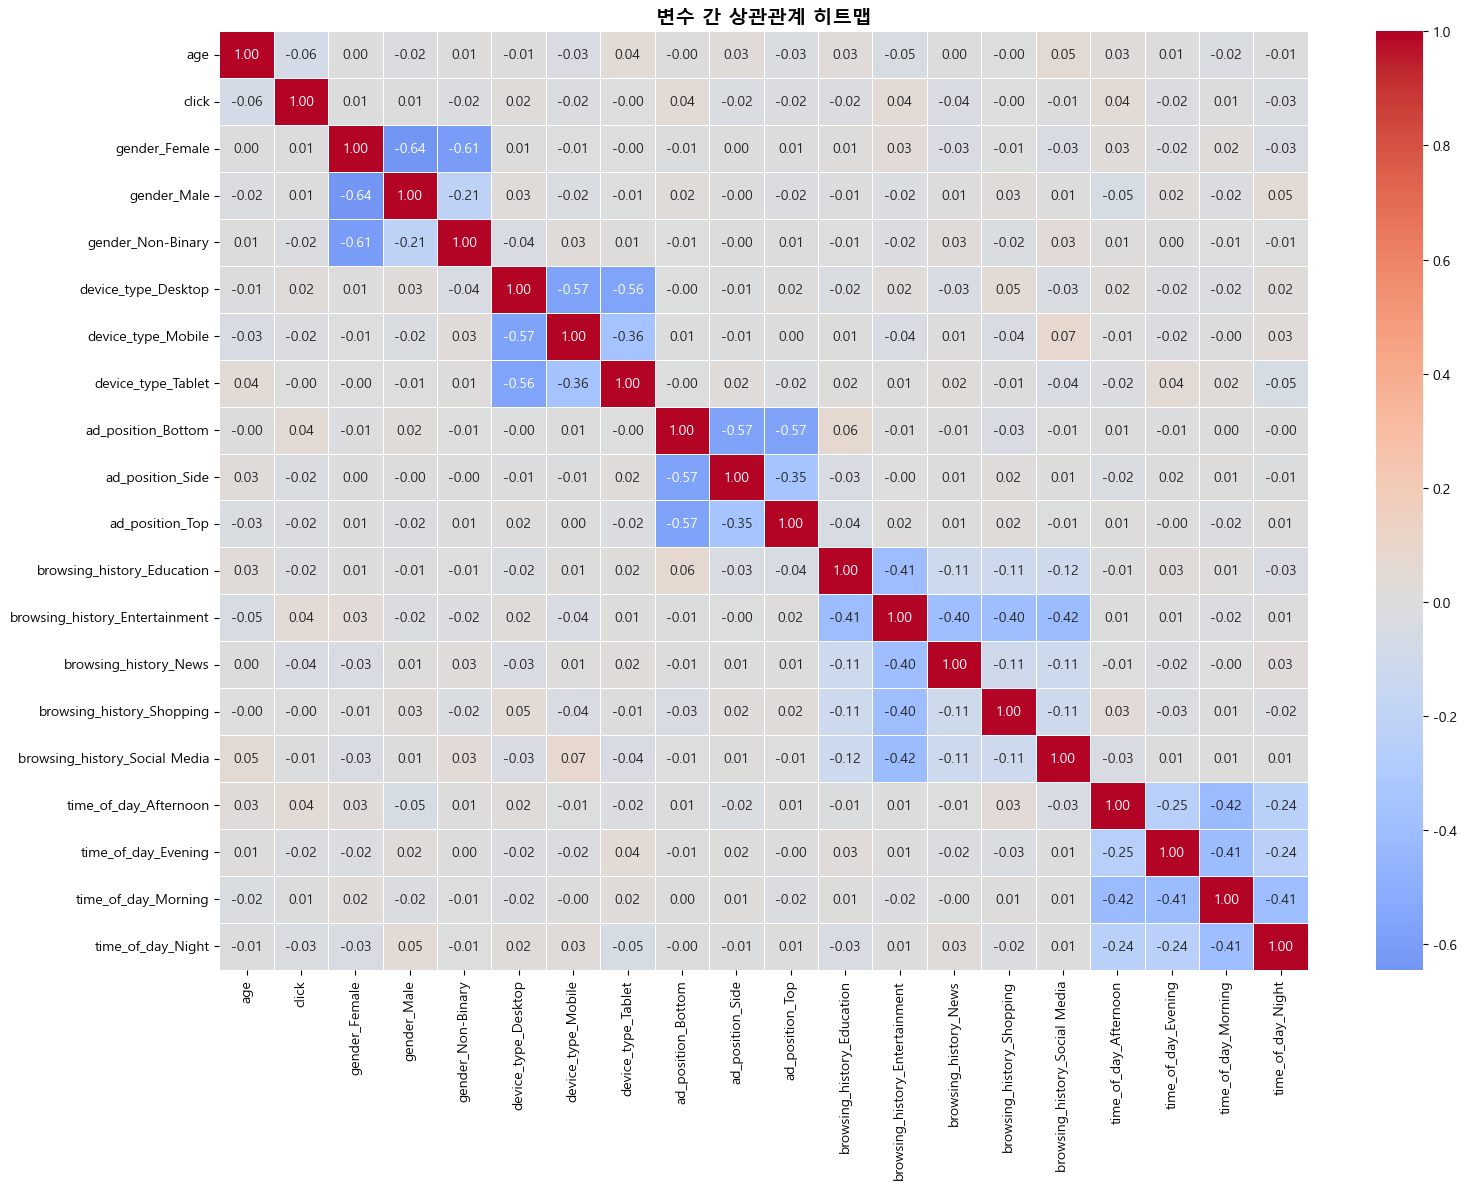

In [ ]:
# 4-1. 상관관계 히트맵
# ----------------------------
# 상관관계(Correlation): 두 변수가 함께 움직이는 정도를 -1 ~ +1 사이 숫자로 표현
# +1에 가까울수록 > 한 변수가 커지면 다른 변수도 커짐 (양의 상관)
# -1에 가까울수록 > 한 변수가 커지면 다른 변수는 작아짐 (음의 상관)
#  0에 가까울수록 > 두 변수 사이에 관계가 거의 없음
# ----------------------------

# .corr(): 모든 수치형 열 사이의 상관계수를 계산해서 표로 반환
corr_matrix = df_encoded.corr()

# 히트맵: 상관관계 표를 색깔로 시각화
# 색이 진할수록 상관관계가 강하다는 의미
plt.figure(figsize=(16, 12))  # 그래프 크기 설정 (가로16, 세로12)

sns.heatmap(
    corr_matrix,
    annot=True,       # annot=True: 각 칸에 숫자(상관계수) 표시
    fmt='.2f',        # fmt='.2f': 소수점 2자리까지만 표시
    cmap='coolwarm',  # cmap: 색상 테마 (파랑=음의 상관, 빨강=양의 상관)
    center=0,         # center=0: 0을 기준으로 색상 중간값 설정
    linewidths=0.5    # linewidths: 칸 사이 구분선 두께
)

plt.title('변수 간 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 결과 해석
- click과 모든 변수의 상관계수가 -0.06 ~ 0.04로 0에 수렴 > 단일 변수만으로는 클릭 여부를 설명하기 어려운 데이터셋임을 수치로 확인
- 진한 빨강/파랑은 데이터 이상이 아님 > One-hot Encoding으로 같은 변수에서 나온 더미끼리 (e.g., gender_Female <-> gender_Male = -0.64) 당연히 강한 음의 상관관계가 나타나는 수학적 특성
- 그나마 가장 큰 값은 age ↔ click = -0.06 > 50대에서 미클릭이 살짝 많았던 경향이 수치로 반영된 것이며, 이 역시 예측력은 매우 낮음. 변수를 하나씩 따로 보면 클릭과의 관계가 거의 없지만, "20대 + 여성 + 아침 + 모바일" 처럼 여러 변수를 조합하면 숨어있던 패턴이 드러날 수 있음 → 이런 변수 간 조합(feature interaction)을 자동으로 찾아주는 Random Forest 같은 모델이 다음 단계에서 필요한 이유

In [ ]:
# 4-2. click과 각 변수의 상관계수 순위
# ----------------------------
# 히트맵은 전체를 보기엔 좋지만 click과의 관계만 따로 뽑아보면 더 명확함
# click 열과 나머지 변수들의 상관계수만 추출해서 크기 순으로 정렬

click_corr = corr_matrix['click'].drop('click')
# corr_matrix['click']: click과 모든 변수의 상관계수 추출
# .drop('click'): click 자기 자신과의 상관계수(항상 1.0)는 제외

click_corr_sorted = click_corr.abs().sort_values(ascending=False)
# .abs(): 음수/양수 상관관계 구분 없이 절댓값으로 변환
#         > 크기만으로 영향력 비교하기 위해
# .sort_values(ascending=False): 절댓값 큰 순서(내림차순)로 정렬

print("click과의 상관계수 (절댓값 기준 내림차순):")
print(click_corr_sorted.round(4))  # 소수점 4자리까지 표시

click과의 상관계수 (절댓값 기준 내림차순):
age                               0.0605
browsing_history_Entertainment    0.0427
browsing_history_News             0.0406
time_of_day_Afternoon             0.0374
ad_position_Bottom                0.0365
time_of_day_Night                 0.0257
ad_position_Side                  0.0229
time_of_day_Evening               0.0210
device_type_Mobile                0.0208
device_type_Desktop               0.0205
ad_position_Top                   0.0187
gender_Non-Binary                 0.0163
browsing_history_Education        0.0158
browsing_history_Social Media     0.0103
gender_Male                       0.0079
time_of_day_Morning               0.0069
gender_Female                     0.0064
browsing_history_Shopping         0.0032
device_type_Tablet                0.0024
Name: click, dtype: float64


# 결과 해석
- 1위 age(0.06)가 가장 높지만 전체적으로 모든 값이 0.06 이하 > 통계적으로 의미있는 상관관계의 기준인 0.1에도 못 미치는 수준으로, 어떤 변수도 click을 단독으로 설명하지 못함
- 상위권은 browsing_history, time_of_day, ad_position 계열이 차지 > 사용자의 관심사(Entertainment, News)와 광고 노출 맥락(시간대, 위치)이 그나마 클릭과 미세하게 연관된 변수들이며, 이는 앞서 클릭률 그래프에서 봤던 경향과 일치
- gender 계열(Female 0.0064, Male 0.0079)과 device_type_Tablet(0.0024)이 최하위 → 성별과 태블릿 기기 여부는 클릭과 거의 무관하며, 다음 단계 모델링에서 중요도가 낮은 변수로 분류될 가능성이 높음

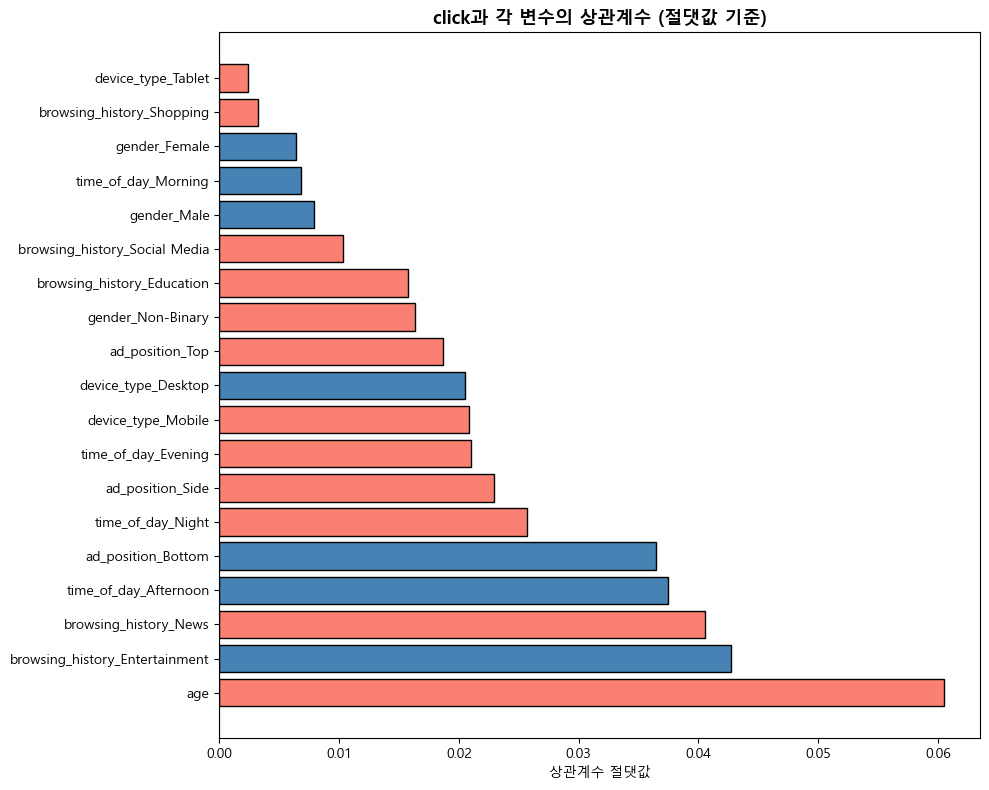

In [80]:
# 4-3. click과 상관관계 막대그래프
# ----------------------------
# 숫자로만 보면 직관적으로 파악하기 어려움 > 막대그래프로 시각화

plt.figure(figsize=(10, 8))

# 양/음의 상관관계를 색으로 구분해서 표시
colors = ['salmon' if x < 0 else 'steelblue' for x in click_corr.loc[click_corr_sorted.index]]
# click_corr.loc[click_corr_sorted.index]: 정렬된 순서에 맞게 원래 부호값 가져오기
# 리스트 컴프리헨션: 값이 음수면 salmon(빨강), 양수면 steelblue(파랑)으로 색 지정

plt.barh(
    click_corr_sorted.index,    # y축: 변수 이름
    click_corr_sorted.values,   # x축: 상관계수 절댓값
    color=colors,
    edgecolor='black'
)
# barh: 가로 막대그래프 (변수 이름이 많아서 세로보다 가로가 읽기 편함)

plt.axvline(x=0, color='black', linewidth=0.8)
# axvline: 수직선 > x=0 기준선 표시

plt.title('click과 각 변수의 상관계수 (절댓값 기준)', fontsize=13, fontweight='bold')
plt.xlabel('상관계수 절댓값')
plt.tight_layout()
plt.show()

# 결과 해석
- 파란색 = 양의 상관관계 > 해당 변수에 해당할수록 클릭이 많아지는 경향
- 빨간색 = 음의 상관관계 > 해당 변수에 해당할수록 클릭이 적어지는 경향